## Using mc-ASTRA representations with patpy

mc-ASTRA models generate sample-level representations, such as patient-by-factor matrices, that can be useful beyond the mc-ASTRA workflow itself. The `patpy` integration provides a small adapter class that wraps a precomputed sample representation so it can be used with `patpy` downstream tools.

`patpy` is an scverse python package for construction and evaluation of patient representations for single-cell data. It does contain alternatives taylored to specific biological questions. 

This is useful when you have already computed a patient map or latent representation in mc-ASTRA and want to reuse it in patpy for distance calculation, embedding, clustering, plotting, or other sample-level analyses.

### Installation

The patpy integration is optional. It is not installed with the base mc-ASTRA package.

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
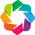

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
# patpy dependencies

import ehrapy as ep  # Like scanpy, but for clinical data analysis. Convenient to preprocess the sample-level data
import scanpy as sc
import patpy  # Datasets, metrics, and analysis of sample representations
import os  # For reading environment variables (e.g. PATPY_GLOSCOPE_GPU)
import pandas as pd  # Working with data frames

# Plotting
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# For displaying benchmarking metrics
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.plots import bar

import time as _time  # For measuring runtime of the methods

# Use a higher figure DPI for crisper plots in the rendered notebook,
# and remove the top/right spines from any seaborn scatter/bar plots.
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['savefig.dpi'] = 150

# mc-ASTRA needs

import mc_astra
import scanpy.external as sce
import numpy as np
import decoupler as dc
import math
import mofaflex as mf
import mudata as md

# integration!!
from mc_astra.integration.patpy import PrecomputedSampleRepresentation

We will showcase how to integrate mc-ASTRA patient maps into patpy and evaluate distinct models against state of the art method `GloScope`.

We'll use the COMBAT dataset analysis (COvid-19 Multi-omics Blood ATlas (COMBAT) Consortium, Cell, 2022), provided by `patpy`. This dataset contains 783k peripheral blood mononuclear cells (PBMC) from 140 samples obtained from COVID-19, Flu, and Sepsis patients as well as from healthy donors.

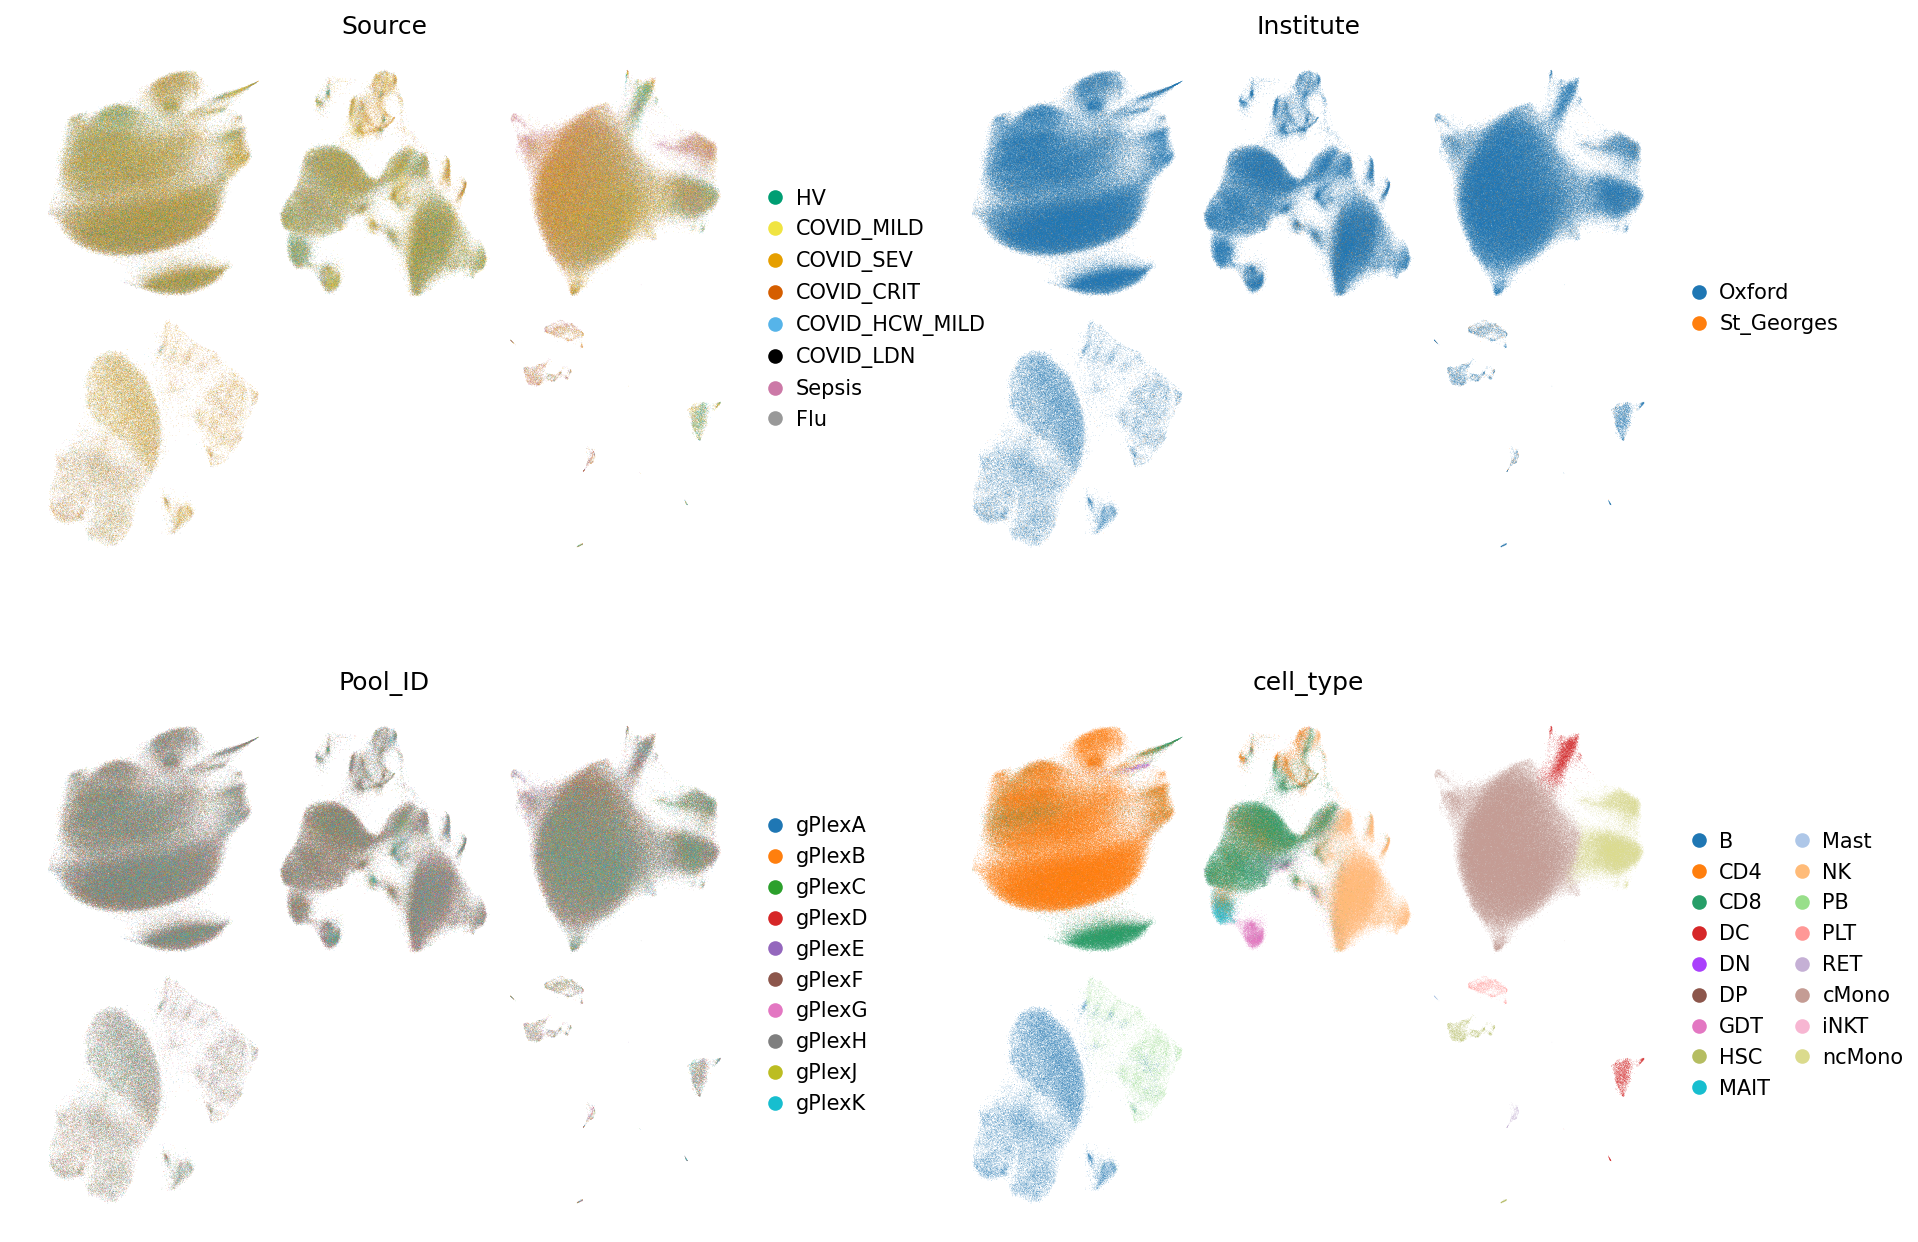

In [3]:
adata = sc.read_h5ad("./data/combat_processed.h5ad")
adata.obs.rename(columns={"Annotation_major_subset": "cell_type"}, inplace=True)
sample_key = 'scRNASeq_sample_ID'  # Set a column containing sample IDs from adata.obs for a custom dataset
cell_type_key = "cell_type"

sc.pl.umap(adata, color=["Source","Institute","Pool_ID", "cell_type"], frameon=False, ncols=2)

### mc-ASTRA processing steps

We process our data as we would do for any other dataset

In [4]:
# We extract the metadata based on our column that is the reference
# Filter adata to only include ileum
# Process adata_raw
metadata = mc_astra.up.extract_metadata_from_obs(obs=adata.obs, groupby=sample_key, sort=False)
pdata = dc.pp.pseudobulk(adata, sample_col=sample_key, groups_col=cell_type_key,layer = "X_raw_counts")
# Manipulations on pdata
pdata.obs = pdata.obs.set_index(sample_key, drop=False)
pdata.obs.index.name = None

In [5]:
# Make list of adatas per pseudobulk cell type
anndata_dict = mc_astra.up.split_anndata_by_celltype(pdata=pdata, grouping=cell_type_key)

# Adding gene expression total counts - TODO add to upstream as a function
for _cell_type, adata_raw in anndata_dict.items():
    # Sum across observations (rows) for each gene (column)
    if hasattr(adata_raw.X, "toarray"):
        # Sparse matrix case
        total_counts = adata_raw.X.sum(axis=0).A1  # returns 1D array
    else:
        total_counts = adata_raw.X.sum(axis=0)  # numpy array

    # Add to .var
    adata_raw.var["total_counts"] = total_counts

In [6]:
# From all the possible samples, let's ask for at least 40%
n_samples = len(metadata.index)
min_samples = math.trunc(n_samples * 0.4)

# Do filters
mc_astra.up.filter_anndata_by_ncells(anndata_dict, min_cells=10)
mc_astra.up.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mc_astra.up.filter_genes_byexpr(anndata_dict, min_count=5, min_prop=0.4)
mc_astra.up.filter_views_by_genes(anndata_dict, min_genes_per_view=100)
mc_astra.up.filter_samples_by_coverage(anndata_dict, threshold=0, min_prop=0.97)
mc_astra.up.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mc_astra.up.save_raw_counts(anndata_dict, layer_name="raw_counts")
mc_astra.up.norm_log(anndata_dict, target_sum=1e6, exclude_highly_expressed=False, max_value=None, center=True)
mc_astra.up.filter_hvgs(anndata_dict, groupby = None, ngroups_cut = 5)
mc_astra.up.filter_smpls_by_nview(anndata_dict, min_views = 5)
mc_astra.up.utils.append_view_to_var(anndata_dict)

Raw counts saved in the 'raw_counts' layer for each AnnData object.
Normalization, log-transformation, and scaling complete for all AnnData objects with target_sum = 1000000.0.


Here we add the essential information to group the model

In [7]:
model_data = md.MuData(anndata_dict)
model_data.obs["study_group"] = model_data.obs.index.map(metadata["Pool_ID"])

## Fitting models
- Regular MOFA (10 Factors)
- Grouped MOFA (10 Factors)

### Basic MOFA model

2026-06-01 08:40:19 | [WARNING] Device cuda is not available. Using default device: cpu


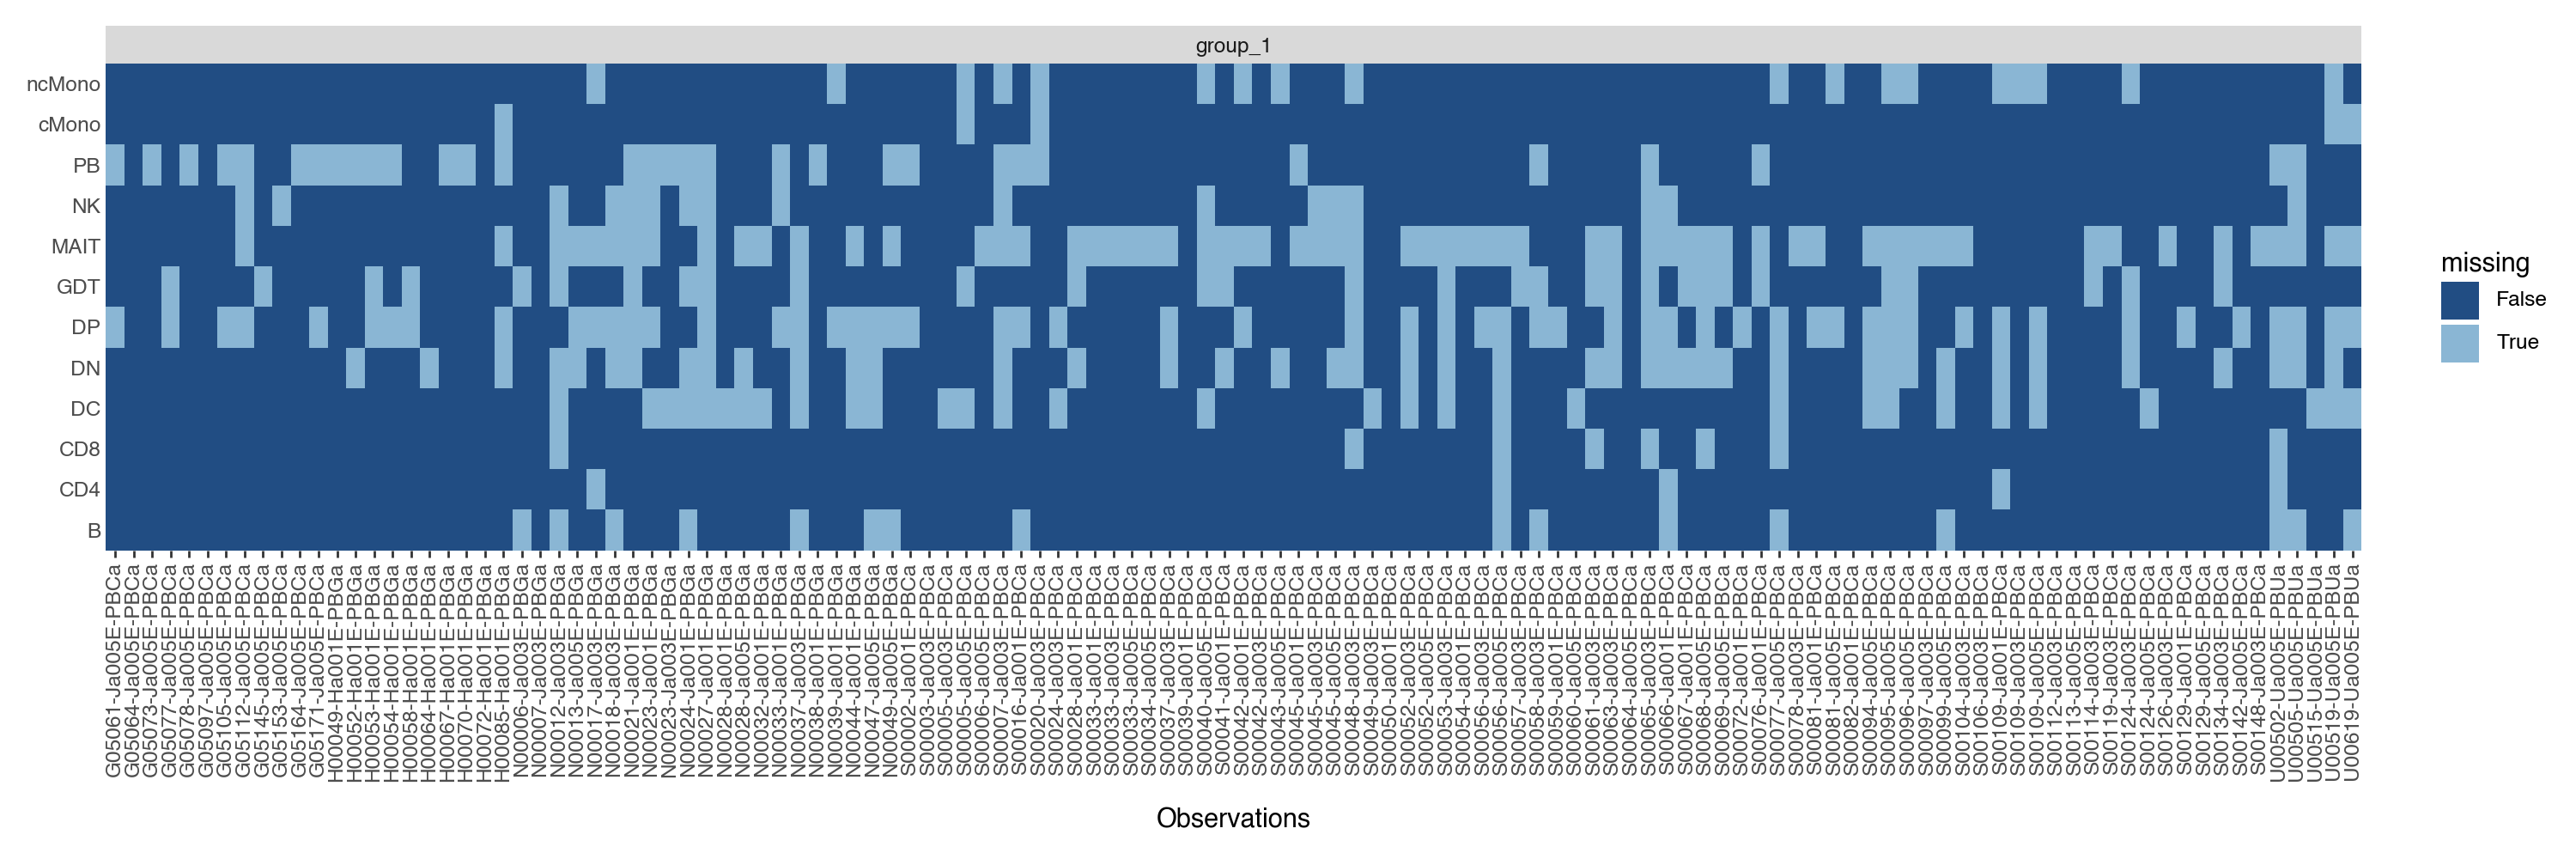

2026-06-01 08:40:25 | [INFO] Initializing factors using 'pca' method...
 57%|█████▋    | 5679/10000 [05:36<04:15, 16.90epoch/s, Loss=3.79e+3]


In [8]:
simple_model = mf.terms.MofaFlex(n_factors=10, weight_prior="SpikeSlab", init_factors="pca") # type: ignore
simple_model.fit(model_data, seed=42, save_path=False, 
                lr=0.01, early_stopper_patience=1000, likelihoods="Normal",plot_data_overview=True)

In order to transform our mc-ASTRA model into a `patpy` compatible class, one needs to use `PrecomputedSampleRepresentation` adding the latent space, and the metadata.

In [10]:
a_simple_model = mc_astra.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=simple_model,
)

# Important to copy!! Otherwise, when we do the next step of filtering, 
# it will mess with the original anndata that is used for the model and 
# thus mess with the model itself
df = pd.DataFrame(a_simple_model.X.copy(), 
                index=a_simple_model.obs_names.copy(), 
                columns=a_simple_model.var_names.copy())

ppy_simple_model = PrecomputedSampleRepresentation(
    representation=df,
    metadata=metadata.copy(),
    metric="euclidean",
)

### Grouped MOFA

Taking `PoolID` as grouping variable

In [12]:
grouped_model = mf.terms.MofaFlex(n_factors=10, weight_prior="SpikeSlab", init_factors="pca") # type: ignore
grouped_model.fit(model_data, seed=42, save_path=False, 
                lr=0.01, early_stopper_patience=1000, likelihoods="Normal",
                plot_data_overview=False, group_by="study_group")

2026-06-01 08:51:59 | [WARNING] Device cuda is not available. Using default device: cpu
2026-06-01 08:52:17 | [INFO] Initializing factors using 'pca' method...
 42%|████▏     | 4235/10000 [06:59<09:30, 10.10epoch/s, Loss=3.53e+3]


In [13]:
a_grouped_model = mc_astra.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=grouped_model,
)

df = pd.DataFrame(a_grouped_model.X.copy(), 
                index=a_grouped_model.obs_names.copy(), 
                columns=a_grouped_model.var_names.copy())

ppy_grouped_model = PrecomputedSampleRepresentation(
    representation=df,
    metadata=metadata.copy(),
    metric="euclidean",
)

## Grouped MOFA with additional compositional information

We can in addition make a classic model with additional compositional information, this will capture two different aspects of tissue organization

In [14]:
from skbio.stats.composition import clr, multi_replace
from anndata import AnnData

def get_cell_count(adata, sample_key, cell_type_key):
    # Compute cell type counts per sample
    cell_counts = (
        adata.obs
        .groupby([sample_key, cell_type_key])
        .size()
        .unstack(fill_value=0)
    )

    # Convert counts to proportions
    prop_data = cell_counts.div(cell_counts.sum(axis=1), axis=0)

    # CLR transformation
    prop_data_clr = clr(multi_replace(prop_data.values))
    prop_data_clr = pd.DataFrame(prop_data_clr, index=prop_data.index, columns=prop_data.columns)

    clr_props_adata = AnnData(prop_data_clr)
    clr_props_adata.obs[sample_key] = clr_props_adata.obs_names
    clr_props_adata.var["compositions"] = clr_props_adata.var_names
    
    return(clr_props_adata)

First we infer the compositional information from the adata and add it to our dictionary of views

In [15]:
clr_props_adata = get_cell_count(adata, sample_key, cell_type_key)
mc_astra.up.utils.append_view_to_var({"clr_comps":clr_props_adata})
anndata_dict["clr_comps"] = clr_props_adata

In [16]:
model_data = md.MuData(anndata_dict)
model_data.obs["study_group"] = model_data.obs.index.map(metadata["Pool_ID"])

groupedclr_model = mf.terms.MofaFlex(n_factors=10, weight_prior="SpikeSlab", init_factors="pca") # type: ignore
groupedclr_model.fit(model_data, seed=42, save_path=False, 
                lr=0.01, early_stopper_patience=1000, likelihoods="Normal",
                plot_data_overview=False, group_by="study_group")

2026-06-01 09:01:19 | [WARNING] Device cuda is not available. Using default device: cpu
2026-06-01 09:01:41 | [INFO] Initializing factors using 'pca' method...
 37%|███▋      | 3707/10000 [06:48<11:33,  9.07epoch/s, Loss=3.48e+3]


In [17]:
a_clrgrouped_model = mc_astra.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=groupedclr_model,
)

df = pd.DataFrame(a_clrgrouped_model.X.copy(), 
                index=a_clrgrouped_model.obs_names.copy(), 
                columns=a_clrgrouped_model.var_names.copy())

ppy_clrgrouped_model = PrecomputedSampleRepresentation(
    representation=df,
    metadata=metadata.copy(),
    metric="euclidean",
)

### Comparing with GloScope

To show different ways of comparing the models, we select `GloScope`, state of the art in pure patient representation.

In [18]:
gloscope = patpy.tl.GloScope_py(
    sample_key=sample_key,
    cell_group_key=cell_type_key,
    layer="X_scVI_batch",
    k=25,
    use_gpu=False,
)

gloscope.prepare_anndata(adata)

D = gloscope.calculate_distance_matrix(force=True)

### Adding all models into a "single representation" for evaluation

Although not the most elegant solution, in order to be able to take advantage of `patpy` evaluation frameworks is to add all results into a single anndata. We will use the anndata generated from mc-ASTRA to ensure that all methods, include the relevant samples

In [19]:
import warnings

def store_representation(meta_adata, method, method_name):
    """
    Store a sample representation in meta_adata after subsetting to samples
    available both in meta_adata.obs_names and method.samples.

    The output AnnData is ordered according to meta_adata.obs_names.
    """

    representation_samples = pd.Index(method.samples)
    meta_samples = pd.Index(meta_adata.obs_names)

    if representation_samples.has_duplicates:
        duplicated = representation_samples[representation_samples.duplicated()].unique().tolist()
        raise ValueError(f"`method.samples` contains duplicated sample IDs: {duplicated}")

    # Keep only samples present in both objects, preserving meta_adata.obs_names order
    common_samples = meta_samples.intersection(representation_samples, sort=False)

    if len(common_samples) == 0:
        raise ValueError("No overlapping samples between `meta_adata.obs_names` and `method.samples`.")

    missing_from_representation = meta_samples.difference(representation_samples)

    if len(missing_from_representation) > 0:
        warnings.warn(
            f"{len(missing_from_representation)} samples in `meta_adata.obs_names` are not present "
            f"in `method.samples` and will be removed.",
            UserWarning,
        )

    # Subset meta_adata to available samples
    meta_adata = meta_adata[common_samples].copy()

    # Integer positions of common samples in method output
    sample_idx = representation_samples.get_indexer(common_samples)

    sample_representation = np.asarray(method.sample_representation)
    distance_matrix = np.asarray(method.calculate_distance_matrix())
    umap_embedding = np.asarray(method.embed("UMAP"))

    if sample_representation.shape[0] != len(representation_samples):
        raise ValueError(
            "`method.sample_representation` rows do not match the number of `method.samples`."
        )

    if distance_matrix.shape != (len(representation_samples), len(representation_samples)):
        raise ValueError(
            "`method.calculate_distance_matrix()` must return a square matrix with one row/column "
            "per sample in `method.samples`."
        )

    if umap_embedding.shape[0] != len(representation_samples):
        raise ValueError(
            "`method.embed('UMAP')` rows do not match the number of `method.samples`."
        )

    meta_adata.obsm[method_name] = sample_representation[sample_idx, :]
    meta_adata.obsm[f"{method_name}_distances"] = distance_matrix[sample_idx][:, sample_idx]
    meta_adata.obsm[f"X_umap_{method_name}"] = umap_embedding[sample_idx, :]

    sc.pp.neighbors(
        meta_adata,
        use_rep=f"{method_name}_distances",
        key_added=f"{method_name}_neighbors",
        metric="precomputed",
    )

    if "sample_representations" not in meta_adata.uns:
        meta_adata.uns["sample_representations"] = []

    if method_name not in meta_adata.uns["sample_representations"]:
        meta_adata.uns["sample_representations"].append(method_name)

    return meta_adata

In [ ]:
meta_adata = a_simple_model.copy()
meta_adata = store_representation(meta_adata, ppy_simple_model, "MOFA_vanilla")
meta_adata = store_representation(meta_adata, gloscope, "GloScope")
meta_adata = store_representation(meta_adata, ppy_grouped_model, "MOFA_grouped")
meta_adata = store_representation(meta_adata, ppy_clrgrouped_model, "MOFA_grouped_clr")


### Benchmark metrics

The benchmark evaluates sample representations by asking whether distances between samples preserve selected metadata properties. 
- **Information retention** measures whether clinical or biological covariates can be recovered from the nearest neighbours of each sample in the representation. For categorical variables, the predicted label is obtained by majority vote among nearest neighbours and scored with a corrected macro-F1 score; for numerical or ordinal variables, neighbour-averaged values are compared with the true values using Spearman correlation. 
- **Batch removal** uses the same logic but applies it to technical covariates, defining a good representation as one where batch variables are difficult to recover.

In [21]:
benchmark_schema = {
    "technical": {
        "Institute": "classification",
        "Pool_ID": "classification",
        },
    "clinical": {
        "Death28": "classification",
        "Outcome": "ranking", 
        "Source": "classification",
        "SARSCoV2PCR": "classification",
    },
}

results = patpy.tl.evaluation.knn_prediction_score(
    meta_adata,
    benchmark_schema,
    representations=meta_adata.uns["sample_representations"],
    n_neighbors=5,
    reverse_technical_score=True,  # To make higher = better
)

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_metric_heatmap_by_covariate_type(
    df,
    score_col="score",
    method_col="representation",
    metric_col="covariate",
    covariate_type_col="covariate_type",
    aggfunc="mean",
    cmap="viridis",
    figsize=None,
    annotate=True,
    annot_fmt=".2f",
    annot_fontsize=8,
):
    """
    Heatmap with:
    - rows: method / representation
    - columns: metric / covariate, grouped by covariate_type
    - values: score
    """

    heatmap_df = (
        df.pivot_table(
            index=method_col,
            columns=[covariate_type_col, metric_col],
            values=score_col,
            aggfunc=aggfunc,
        )
        .sort_index(axis=0)
        .sort_index(axis=1)
    )

    if figsize is None:
        figsize = (
            max(6, 0.45 * heatmap_df.shape[1]),
            max(3, 0.35 * heatmap_df.shape[0]),
        )

    fig, ax = plt.subplots(figsize=figsize)

    values = heatmap_df.values

    im = ax.imshow(
        values,
        aspect="auto",
        cmap=cmap,
    )

    # Add text inside cells
    if annotate:
        vmin = np.nanmin(values)
        vmax = np.nanmax(values)
        threshold = vmin + 0.5 * (vmax - vmin)

        for i in range(heatmap_df.shape[0]):
            for j in range(heatmap_df.shape[1]):
                value = heatmap_df.iloc[i, j]

                if pd.notna(value):
                    text_color = "white" if value < threshold else "black"

                    ax.text(
                        j,
                        i,
                        f"{value:{annot_fmt}}",
                        ha="center",
                        va="center",
                        fontsize=annot_fontsize,
                        color=text_color,
                    )

    # Row labels
    ax.set_yticks(np.arange(heatmap_df.shape[0]))
    ax.set_yticklabels(heatmap_df.index)

    # Column labels: show only metric/covariate names
    metric_labels = heatmap_df.columns.get_level_values(metric_col)

    ax.set_xticks(np.arange(heatmap_df.shape[1]))
    ax.set_xticklabels(metric_labels, rotation=90)

    # Add covariate_type group labels and separators
    covariate_types = heatmap_df.columns.get_level_values(covariate_type_col)

    boundaries = []
    group_centers = []

    for cov_type in covariate_types.unique():
        positions = np.where(covariate_types == cov_type)[0]

        center = (positions[0] + positions[-1]) / 2
        group_centers.append((center, cov_type))

        end = positions[-1]
        if end < heatmap_df.shape[1] - 1:
            boundaries.append(end + 0.5)

    for boundary in boundaries:
        ax.axvline(boundary, color="white", linewidth=2)

    # Covariate type labels above the heatmap
    for center, cov_type in group_centers:
        ax.text(
            center,
            -1.2,
            cov_type,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    ax.set_xlabel(metric_col)
    ax.set_ylabel(method_col)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(score_col)

    plt.tight_layout()

    return fig, ax, heatmap_df

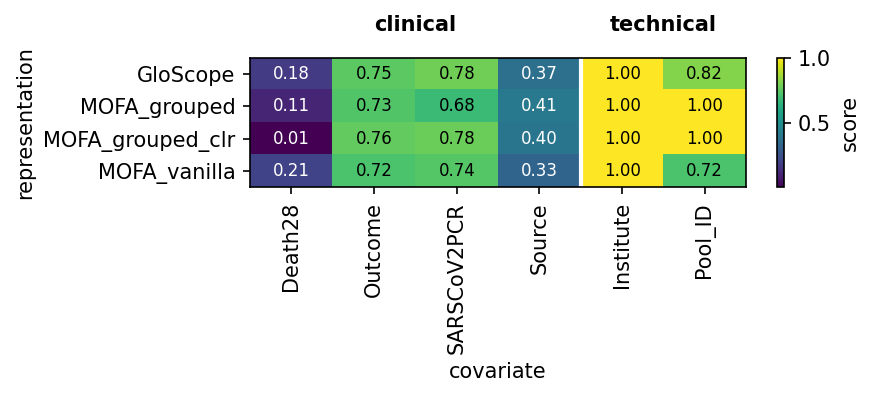

In [26]:
fig, ax, heatmap_df = plot_metric_heatmap_by_covariate_type(results)

In the plot above, individual values represent the evaluation of the recovery of a covariate of interest by the latent space. In practical terms, the patient maps do capture the variability of patients across distinct relevant features with similar trends, as mentioned by the original GloScope paper. We would like to highlight other differences between the models.

### Input and modeling assumptions

| Tool | Statistical or ML principle | Data type | Flexibility of input | Missing data | Batch correction |
|---|---|---|---|---|---|
| mc-ASTRA | Grouped factor analysis with structured priors through MOFA-FLEX. | Multiview patient representations, i.e. collections of patients × features matrices. | By default, pseudobulk gene expression data for each cell type of interest. However, cellular composition, spatial organization, and other patient-level representations can also be included in the model. | Patients can miss complete views or individual features within views. | Explicitly managed in the model. |
| GloScope | Represents each biological sample as an empirical probability distribution of its cells in a shared low-dimensional cell-state space, then compares samples using pairwise statistical divergence between these estimated distributions. | Low-dimensional representation of single-cell data, such as PCA or scVI. | Any low-dimensional representation can be used. Joint multimodal latent spaces from the same samples could also be included. | Missingness is handled in the low-dimensional representation. However, it is treated as a characteristic of the patient/sample distribution. | Implicitly managed within the low-dimensional representation. |

### Output and interpretability

| Tool | Latent space | Recovered variance | Interpretability of latent space | Pairwise distances |
|---|---|---|---|---|
| mc-ASTRA | Yes. | Yes, both at the level of latent variables and views. | Yes, both at the level of features and views. | Yes, if calculated from the latent variables. |
| GloScope | Yes, built from the pairwise distance matrix, for example with multidimensional scaling. | No. | No. | Yes. |

### Some comments regarding the metrics

Evaluation based on information retention should be interpreted with caution because it measures how well selected annotations can be recovered from local neighbourhoods in the full representation, rather than the intrinsic quality of the patient map. In other words, the metric asks whether samples that are close in the latent space also share known clinical or technical covariates.

This is useful as a diagnostic, but it should not be treated as a general measure of representation quality. In the benchmark results, the tested methods recover several clinical and technical covariates at broadly similar levels, suggesting that small numerical differences are unlikely to provide a robust basis for method selection. More importantly, these scores can disadvantage richer representations. If only a subset of latent variables captures the available clinical metadata, while other axes capture orthogonal biological variation, the full-space neighbourhood structure may no longer be dominated by the annotated covariates. A lower information-retention score may therefore reflect the presence of additional, unannotated structure rather than poorer representation quality.

For this reason, we treat these metrics as annotation-alignment diagnostics. We then complement them with criteria that evaluate properties of the patient map itself, including explained variance, interpretability, and the biological coherence of the recovered latent factors.

Although it is reasonable to expect measured clinical variables to be reflected in molecular profiles, these variables are unlikely to explain all relevant gene expression variability. In fact, one of the motivations for generating molecular profiles is to capture disease-relevant structure that is not fully represented by standard clinical annotations. The following example illustrates this point.

### MOFA grouped with compositions

We reconstructed multicellular gene expression and cellular composition using a grouped MOFA model with 10 factors. However, not all factors were associated with the clinical or technical variables included in the benchmark. In particular, Factors 6, 7, and 8 did not show clear associations with the selected variables of interest. This raises a practical question: if we remove these factors from the representation, do the benchmark results change?

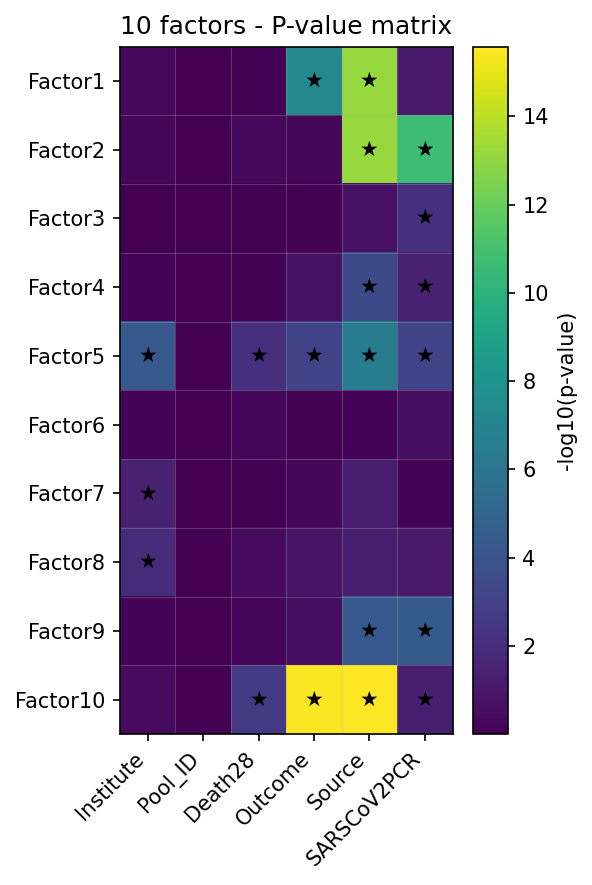

In [63]:
# Get the p-value matrix for the associations of interest (adjusted)
all_assocs = mc_astra.down.get_pval_matrix(a_clrgrouped_model,["Institute", "Pool_ID", "Death28", "Outcome", "Source", "SARSCoV2PCR"])
mc_astra.pl.pl.plot_pval_tiles(all_assocs, title="10 factors - P-value matrix",star_threshold=0.05)
plt.show()

In [77]:
fs = ["Factor" + str(i) for i in range(a_clrgrouped_model.X.shape[1]+1) if i not in [0,6,7,8]]
red_model = a_clrgrouped_model[:,fs].copy()

df = pd.DataFrame(red_model.X.copy(), 
                index=red_model.obs_names.copy(), 
                columns=red_model.var_names.copy())

ppy_red_model = PrecomputedSampleRepresentation(
    representation=df,
    metadata=metadata.copy(),
    metric="euclidean",
)

meta_adata = store_representation(meta_adata, ppy_red_model, "MOFA_grouped_clr_red")


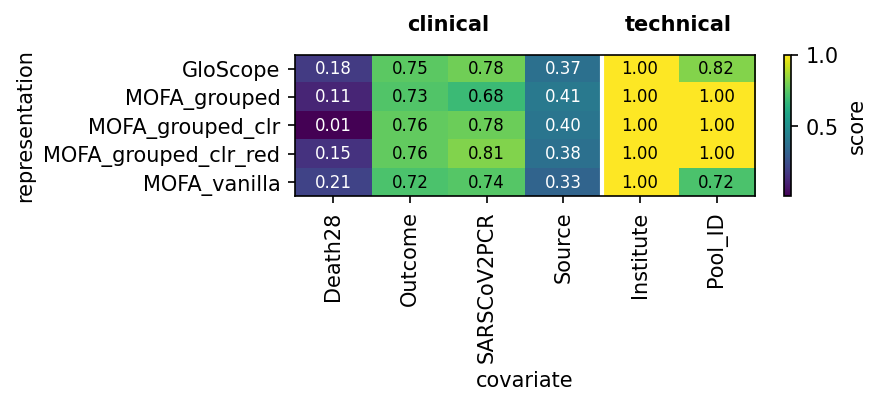

In [78]:
results = patpy.tl.evaluation.knn_prediction_score(
    meta_adata,
    benchmark_schema,
    representations=meta_adata.uns["sample_representations"],
    n_neighbors=5,
    reverse_technical_score=True,  # To make higher = better
)

fig, ax, heatmap_df = plot_metric_heatmap_by_covariate_type(results)

Compared with the original grouped model with compositions, the reduced representation improves prediction of death after 28 days (`Death28`) and performs better than GloScope for the remaining benchmarked covariates, although the absolute differences between methods are small and should be interpreted cautiously. This result suggests that removing factors not aligned with the selected metadata can improve the information-retention score.

However, this improvement comes at a cost. To quantify this, we examined the explained variance captured by each factor across views and groups. When inspecting the top view–factor pairs, it becomes clear that excluding Factors 6, 7, and 8 removes a substantial fraction of structured variability from some pools and cell types, reaching up to 50% in specific cases. Two of these factors appear to be associated with `Institute`, suggesting that part of this variability may reflect technical or cohort-related structure. However, one factor is not explained by the available covariates and appears to account for a large fraction of the excluded variability.

In [85]:
a_clrgrouped_model[:,["Factor6", "Factor7", "Factor8"]].var.sum(0).sort_values(ascending=False).head(10)

PB:gPlexE      0.521059
PB:gPlexJ      0.367761
PB:gPlexA      0.359520
MAIT:gPlexB    0.343469
PB:gPlexB      0.341387
PB:gPlexD      0.283954
PB:gPlexH      0.269391
PB:gPlexG      0.257348
DC:gPlexD      0.256202
PB:gPlexF      0.214500
dtype: float64

In [91]:
a_clrgrouped_model[:,["Factor6"]].var.sum(0).sort_values(ascending=False).head(10)

PB:gPlexE      0.516666
PB:gPlexA      0.353326
PB:gPlexJ      0.344216
PB:gPlexB      0.333276
PB:gPlexD      0.275638
PB:gPlexG      0.234754
PB:gPlexH      0.230460
PB:gPlexF      0.209301
MAIT:gPlexB    0.150717
DP:gPlexK      0.140664
dtype: float64

This example highlights the limitation of relying exclusively on metadata-recovery metrics. A representation can score better after removing latent axes that are not aligned with the benchmark annotations, even when those axes explain substantial structure in the data. The relevant question is therefore not only whether a patient map recovers known clinical variables, but also whether it captures interpretable and biologically meaningful variation beyond those variables.

Thus, richer representations should not be penalized solely because they capture orthogonal variability. Instead, this additional structure should be evaluated directly through explained variance, factor interpretability, association with technical covariates, and biological coherence.